***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.9 偏振成像与 RM 入门](9_9_polarization_imaging.ipynb)
    * 下一节： [9.x 延伸阅读与后续实践方向](9_x_further_reading_and_workflow.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.10 短间距、单碟与联合成像：missing flux、negative bowl 与 feather

到了这一步，我们终于遇到现代毫米波和厘米波阵列处理中最常见、也最容易让初学者困惑的问题之一：**为什么图像分辨率看起来很好，但总通量明显不对？**

根本原因是：干涉阵并不直接测天空图像，而是在 $uv$ 平面上取样。如果最短基线不够短，那么最靠近零空间频率的那一圈信息就没有被测到。于是：

- 大尺度结构会被低估，甚至几乎消失；
- 图像里常常出现围绕源分布的 `negative bowl`；
- 单看干涉阵图像时，容易误以为源本身就只有紧致成分。

这也是为什么真实工作流里，常常需要把干涉阵与单碟数据联合起来。单碟擅长恢复大尺度总功率，但角分辨率差；干涉阵擅长恢复小尺度细节，但缺零间距与短间距。两者互补，才更接近真实天空。

这一节用一个完全自包含的二维实验，把四件事情讲清楚：

- 缺短间距时，图像会怎样丢失大尺度通量；
- 单碟为什么能补回总通量，但会显著模糊紧致结构；
- `feather` 这种频域加权组合在做什么；
- 为什么 feather 不是“万能恢复”，参数和数据质量仍然决定结果。


***


In [2]:
def flux_normalized_gaussian(
    x,
    y,
    x0,
    y0,
    sigma_x,
    sigma_y,
    cell_arcsec,
    theta_deg=0.0,
):
    theta = np.deg2rad(theta_deg)
    xr = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
    yr = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)
    profile = np.exp(-0.5 * ((xr / sigma_x) ** 2 + (yr / sigma_y) ** 2))
    profile /= profile.sum() * (cell_arcsec**2)
    return profile


def gaussian_kernel(npix, sigma_pix):
    coords = np.arange(npix) - npix // 2
    xx, yy = np.meshgrid(coords, coords)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma_pix**2))
    kernel /= kernel.sum()
    return kernel


def fft_convolve_same(image, kernel):
    image_ft = np.fft.fft2(image)
    kernel_ft = np.fft.fft2(np.fft.ifftshift(kernel))
    return np.real(np.fft.ifft2(image_ft * kernel_ft))


def integrated_flux(image, mask, cell_arcsec):
    return np.sum(image[mask]) * (cell_arcsec**2)


def radial_profile(image, radius_grid, bin_edges):
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    values = np.full(centers.shape, np.nan, dtype=float)
    for i, (r0, r1) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        mask = (radius_grid >= r0) & (radius_grid < r1)
        if np.any(mask):
            values[i] = np.mean(image[mask])
    return centers, values


def aperture_curve(image, radius_grid, radii, cell_arcsec):
    return np.array(
        [integrated_flux(image, radius_grid <= rr, cell_arcsec) for rr in radii]
    )


def feather_combine(int_image, sd_image, k_radius, k_join):
    w_sd = np.exp(-(k_radius / k_join) ** 2)
    ft_combined = (
        (1.0 - w_sd) * np.fft.fft2(int_image)
        + w_sd * np.fft.fft2(sd_image)
    )
    return np.real(np.fft.ifft2(ft_combined)), w_sd


npix = 96
cell_arcsec = 2.0
coords = (np.arange(npix) - npix // 2) * cell_arcsec
x_grid, y_grid = np.meshgrid(coords, coords)
radius_grid = np.sqrt(x_grid**2 + y_grid**2)

true_sky = np.zeros((npix, npix))
true_sky += 1.00 * flux_normalized_gaussian(
    x_grid, y_grid, 0.0, 0.0, 16.0, 14.0, cell_arcsec
)
true_sky += 0.35 * flux_normalized_gaussian(
    x_grid, y_grid, -10.0, 18.0, 14.0, 4.0, cell_arcsec, theta_deg=28.0
)
true_sky += 0.55 * flux_normalized_gaussian(
    x_grid, y_grid, 0.0, 0.0, 3.4, 2.8, cell_arcsec
)
true_sky += 0.20 * flux_normalized_gaussian(
    x_grid, y_grid, 28.0, -16.0, 4.5, 3.2, cell_arcsec, theta_deg=-10.0
)
true_sky += 0.14 * flux_normalized_gaussian(
    x_grid, y_grid, -26.0, -22.0, 5.0, 4.0, cell_arcsec, theta_deg=20.0
)

kx = np.fft.fftfreq(npix, d=cell_arcsec)
ky = np.fft.fftfreq(npix, d=cell_arcsec)
kx_grid, ky_grid = np.meshgrid(kx, ky)
k_radius = np.sqrt(kx_grid**2 + ky_grid**2)

mrs_arcsec = 56.0
k_short = 1.0 / mrs_arcsec
uv_transfer = k_radius / (k_radius + k_short)
uv_transfer[0, 0] = 0.0

restoring_beam = gaussian_kernel(npix, sigma_pix=1.2)
single_dish_beam = gaussian_kernel(npix, sigma_pix=5.0)
restoring_fwhm_arcsec = 2.355 * 1.2 * cell_arcsec
single_dish_fwhm_arcsec = 2.355 * 5.0 * cell_arcsec

interferometer_image = fft_convolve_same(
    np.real(np.fft.ifft2(np.fft.fft2(true_sky) * uv_transfer)),
    restoring_beam,
)
interferometer_image += 1.5e-4 * RNG.normal(size=(npix, npix))

single_dish_image = fft_convolve_same(true_sky, single_dish_beam)
single_dish_image += 8.0e-5 * RNG.normal(size=(npix, npix))

conservative_join = 0.012
balanced_join = 0.018
aggressive_join = 0.024

feather_conservative, feather_weight_conservative = feather_combine(
    interferometer_image, single_dish_image, k_radius, conservative_join
)
feather_balanced, feather_weight_balanced = feather_combine(
    interferometer_image, single_dish_image, k_radius, balanced_join
)
feather_aggressive, feather_weight_aggressive = feather_combine(
    interferometer_image, single_dish_image, k_radius, aggressive_join
)

science_mask = radius_grid <= 62.0
diffuse_mask = (radius_grid >= 10.0) & (radius_grid <= 45.0)
compact_mask = radius_grid <= 8.0
negative_bowl_mask = (radius_grid >= 42.0) & (radius_grid <= 60.0)

image_vmin = -6.0e-5
image_vmax = true_sky.max()


### 9.10.1 干涉阵为什么会“看见细节，却看不见总通量”

下面这组三图对应的是同一片天空：

- `true sky`：真实天空亮度分布；
- `interferometer only`：缺短间距后得到的干涉阵图像；
- `single-dish only`：单碟总功率图像。

这个实验里，我们把干涉阵的大尺度转折尺度设在约 `56 arcsec`。这不是严格阵列公式推导，而是一个教学上的等效 `MRS`（maximum recoverable scale）近似，用来直观表示“从这附近开始，大尺度信息会越来越不可靠”。


设定的等效最大可恢复尺度 MRS ≈ 56.0 arcsec
干涉阵恢复束 FWHM ≈ 5.7 arcsec
单碟束 FWHM ≈ 23.6 arcsec
真实天空在科学区域内的总通量 ≈ 2.240 Jy
干涉阵单独成像得到的总通量 ≈ 0.257 Jy
单碟图像得到的总通量 ≈ 2.247 Jy


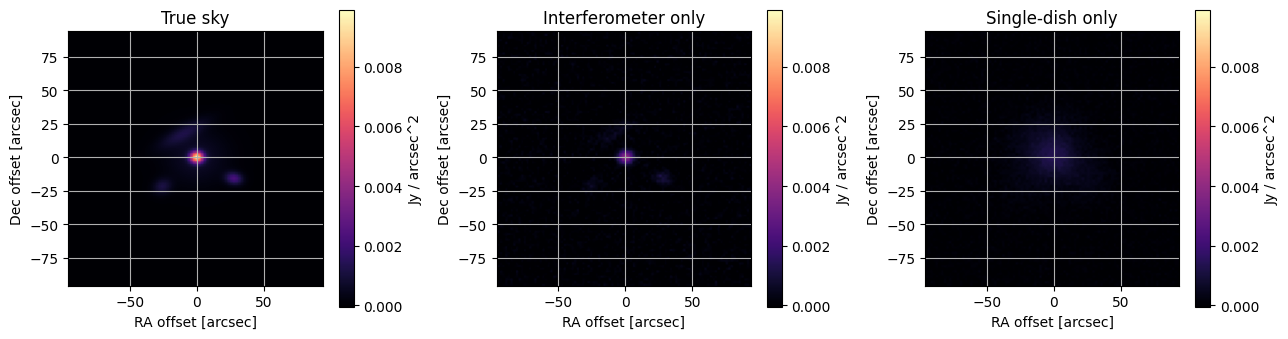

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.0))

for ax, image, title in [
    (axes[0], true_sky, "True sky"),
    (axes[1], interferometer_image, "Interferometer only"),
    (axes[2], single_dish_image, "Single-dish only"),
]:
    im = ax.imshow(
        image,
        origin="lower",
        extent=[coords[0], coords[-1], coords[0], coords[-1]],
        cmap="magma",
        vmin=image_vmin,
        vmax=image_vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("RA offset [arcsec]")
    ax.set_ylabel("Dec offset [arcsec]")
    plt.colorbar(im, ax=ax, shrink=0.82, label="Jy / arcsec^2")

plt.tight_layout()

true_total_flux = integrated_flux(true_sky, science_mask, cell_arcsec)
int_total_flux = integrated_flux(interferometer_image, science_mask, cell_arcsec)
sd_total_flux = integrated_flux(single_dish_image, science_mask, cell_arcsec)

print(f"设定的等效最大可恢复尺度 MRS ≈ {mrs_arcsec:.1f} arcsec")
print(f"干涉阵恢复束 FWHM ≈ {restoring_fwhm_arcsec:.1f} arcsec")
print(f"单碟束 FWHM ≈ {single_dish_fwhm_arcsec:.1f} arcsec")
print(f"真实天空在科学区域内的总通量 ≈ {true_total_flux:.3f} Jy")
print(f"干涉阵单独成像得到的总通量 ≈ {int_total_flux:.3f} Jy")
print(f"单碟图像得到的总通量 ≈ {sd_total_flux:.3f} Jy")


这里最关键的判断是：**干涉阵图像中的“亮源还在”并不意味着通量没有丢。** 真正先消失的往往是大尺度背景、扩展包层和低空间频率结构。


### 9.10.2 missing flux 与 negative bowl 在图像上怎么表现

缺短间距的后果通常至少有两个：

- 积分通量显著偏低；
- 源外围出现系统性的负碗结构。

下面分别画出径向平均亮度剖面和累计孔径通量曲线。这样可以直接看到：

- 干涉阵图像在大半径处会被拉到负值附近；
- 单碟图像在总通量上更接近真实天空，但紧致峰值被明显压低。


扩展成分在真实天空中的积分通量 ≈ 1.502 Jy
扩展成分在干涉阵图像中的积分通量 ≈ 0.123 Jy
扩展成分在单碟图像中的积分通量 ≈ 1.814 Jy
干涉阵图像负碗区域的中位亮度 ≈ -4.55e-05 Jy / arcsec^2


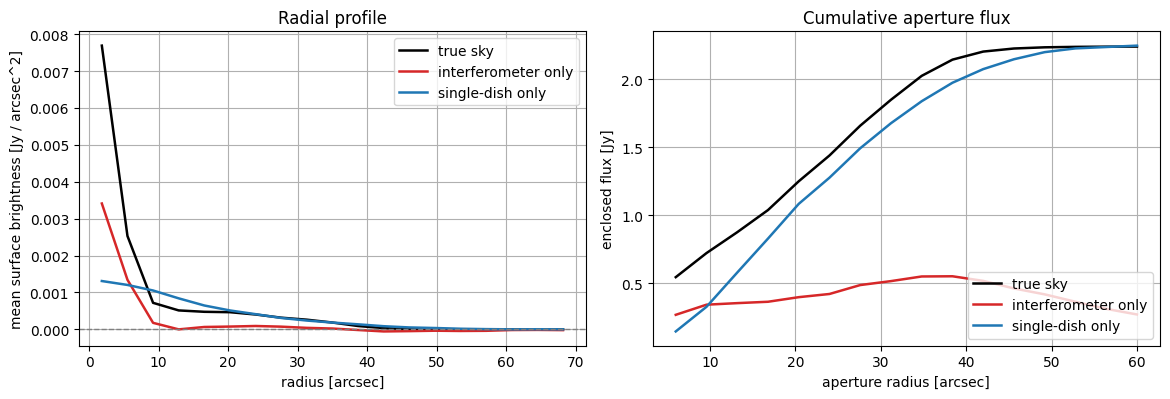

In [4]:
radial_bins = np.linspace(0.0, 70.0, 20)
radial_centers, true_profile = radial_profile(true_sky, radius_grid, radial_bins)
_, int_profile = radial_profile(interferometer_image, radius_grid, radial_bins)
_, sd_profile = radial_profile(single_dish_image, radius_grid, radial_bins)

aperture_radii = np.linspace(6.0, 60.0, 16)
true_curve = aperture_curve(true_sky, radius_grid, aperture_radii, cell_arcsec)
int_curve = aperture_curve(interferometer_image, radius_grid, aperture_radii, cell_arcsec)
sd_curve = aperture_curve(single_dish_image, radius_grid, aperture_radii, cell_arcsec)

diffuse_true_flux = integrated_flux(true_sky, diffuse_mask, cell_arcsec)
diffuse_int_flux = integrated_flux(interferometer_image, diffuse_mask, cell_arcsec)
diffuse_sd_flux = integrated_flux(single_dish_image, diffuse_mask, cell_arcsec)
bowl_median = np.median(interferometer_image[negative_bowl_mask])

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.1))

axes[0].plot(radial_centers, true_profile, color="black", lw=1.8, label="true sky")
axes[0].plot(radial_centers, int_profile, color="tab:red", lw=1.8, label="interferometer only")
axes[0].plot(radial_centers, sd_profile, color="tab:blue", lw=1.8, label="single-dish only")
axes[0].axhline(0.0, color="gray", ls="--", lw=1.0)
axes[0].set_xlabel("radius [arcsec]")
axes[0].set_ylabel("mean surface brightness [Jy / arcsec^2]")
axes[0].set_title("Radial profile")
axes[0].legend(loc="upper right")

axes[1].plot(aperture_radii, true_curve, color="black", lw=1.8, label="true sky")
axes[1].plot(aperture_radii, int_curve, color="tab:red", lw=1.8, label="interferometer only")
axes[1].plot(aperture_radii, sd_curve, color="tab:blue", lw=1.8, label="single-dish only")
axes[1].set_xlabel("aperture radius [arcsec]")
axes[1].set_ylabel("enclosed flux [Jy]")
axes[1].set_title("Cumulative aperture flux")
axes[1].legend(loc="lower right")

plt.tight_layout()

print(f"扩展成分在真实天空中的积分通量 ≈ {diffuse_true_flux:.3f} Jy")
print(f"扩展成分在干涉阵图像中的积分通量 ≈ {diffuse_int_flux:.3f} Jy")
print(f"扩展成分在单碟图像中的积分通量 ≈ {diffuse_sd_flux:.3f} Jy")
print(f"干涉阵图像负碗区域的中位亮度 ≈ {bowl_median:.2e} Jy / arcsec^2")


这就是为什么真实数据处理中，看到负碗时不能只把它当成“去卷积还没收干净”。很多时候，它反映的是**低空间频率本来就没有被测到**。


### 9.10.3 用 feather 把低频交给单碟，把高频交给干涉阵

`feather` 的核心思想非常直接：

- 在低空间频率处，更相信单碟；
- 在高空间频率处，更相信干涉阵；
- 在中间区域做平滑过渡。

下面先看一个“balanced feather”结果，也就是这节里推荐作为默认教学展示的组合。


balanced feather 后的总通量 ≈ 2.176 Jy
balanced feather 后的扩展成分通量 ≈ 1.540 Jy
balanced feather 后紧致核心 8'' 孔径通量 ≈ 0.401 Jy
干涉阵单独成像只保留了总通量的 11.5% ，balanced feather 恢复到 97.2%
balanced feather 的中心峰值约为单碟图像的 3.34 倍


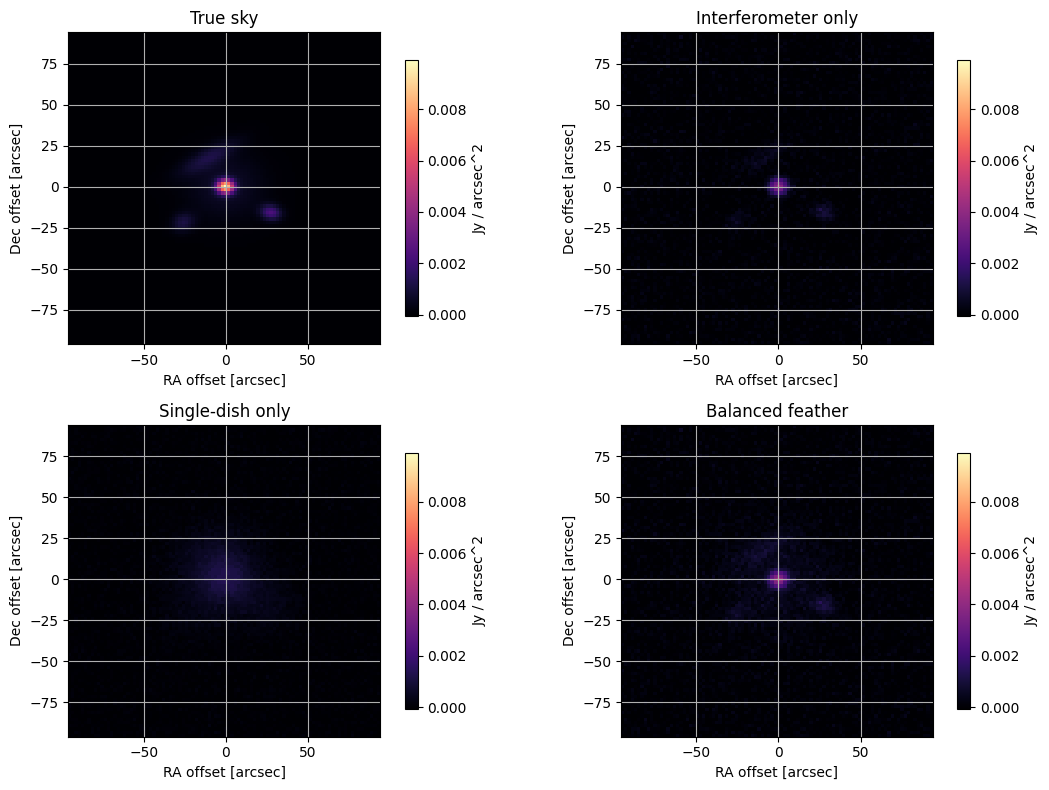

In [5]:
feather_total_flux = integrated_flux(feather_balanced, science_mask, cell_arcsec)
feather_diffuse_flux = integrated_flux(feather_balanced, diffuse_mask, cell_arcsec)
feather_compact_flux = integrated_flux(feather_balanced, compact_mask, cell_arcsec)

fig, axes = plt.subplots(2, 2, figsize=(11.2, 8.0))

for ax, image, title in [
    (axes[0, 0], true_sky, "True sky"),
    (axes[0, 1], interferometer_image, "Interferometer only"),
    (axes[1, 0], single_dish_image, "Single-dish only"),
    (axes[1, 1], feather_balanced, "Balanced feather"),
]:
    im = ax.imshow(
        image,
        origin="lower",
        extent=[coords[0], coords[-1], coords[0], coords[-1]],
        cmap="magma",
        vmin=image_vmin,
        vmax=image_vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("RA offset [arcsec]")
    ax.set_ylabel("Dec offset [arcsec]")
    plt.colorbar(im, ax=ax, shrink=0.82, label="Jy / arcsec^2")

plt.tight_layout()

print(f"balanced feather 后的总通量 ≈ {feather_total_flux:.3f} Jy")
print(f"balanced feather 后的扩展成分通量 ≈ {feather_diffuse_flux:.3f} Jy")
print(f"balanced feather 后紧致核心 8'' 孔径通量 ≈ {feather_compact_flux:.3f} Jy")
print(
    f"干涉阵单独成像只保留了总通量的 {100.0 * int_total_flux / true_total_flux:.1f}% ，"
    f"balanced feather 恢复到 {100.0 * feather_total_flux / true_total_flux:.1f}%"
)
print(
    f"balanced feather 的中心峰值约为单碟图像的 "
    f"{feather_balanced[npix // 2, npix // 2] / single_dish_image[npix // 2, npix // 2]:.2f} 倍"
)


这里要注意一个非常重要的专业边界：`feather` 确实能把低频补回来，但它**不是联合去卷积的完全替代品**。紧致结构的最终峰值、PSF 一致性和不同数据集之间的相对标定，依然会限制结果质量。


### 9.10.4 feather 权重也有取舍：保守、平衡、激进

如果让单碟在频域里占得太少，缺失的大尺度仍会补不回来；如果让单碟占得太多，又会把中尺度和小尺度结构拉得过平。

下面比较三种过渡尺度：

- conservative：单碟只负责更低频的一小段；
- balanced：这节推荐的默认方案；
- aggressive：让单碟在更宽的频率范围内参与。


conservative feather: 总通量 = 2.073 Jy, 扩展成分 = 1.391 Jy, 中心峰值 = 0.0047 Jy / arcsec^2
balanced feather: 总通量 = 2.176 Jy, 扩展成分 = 1.540 Jy, 中心峰值 = 0.0048 Jy / arcsec^2
aggressive feather: 总通量 = 2.209 Jy, 扩展成分 = 1.605 Jy, 中心峰值 = 0.0047 Jy / arcsec^2


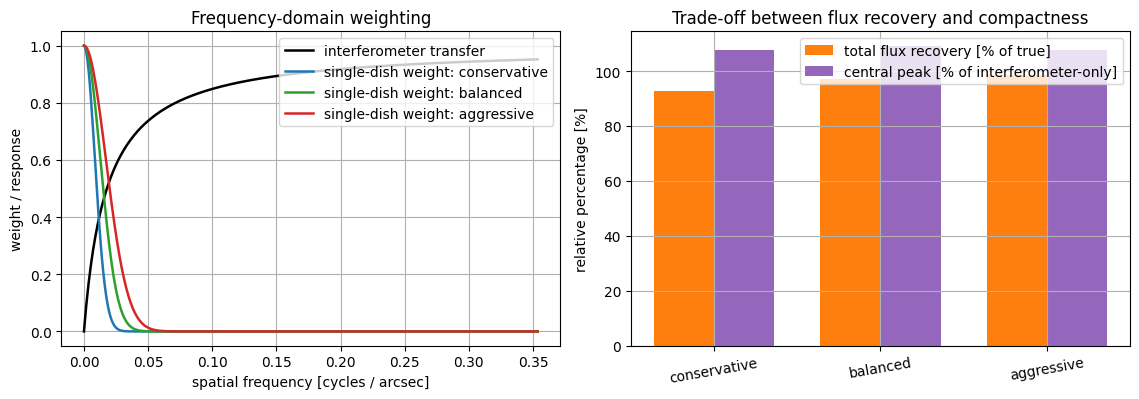

In [6]:
k_axis = np.linspace(0.0, np.max(k_radius), 400)
w_cons_axis = np.exp(-(k_axis / conservative_join) ** 2)
w_bal_axis = np.exp(-(k_axis / balanced_join) ** 2)
w_aggr_axis = np.exp(-(k_axis / aggressive_join) ** 2)

strategy_images = {
    "conservative": feather_conservative,
    "balanced": feather_balanced,
    "aggressive": feather_aggressive,
}
strategy_total = np.array(
    [
        integrated_flux(strategy_images[name], science_mask, cell_arcsec)
        for name in ["conservative", "balanced", "aggressive"]
    ]
)
strategy_peak = np.array(
    [strategy_images[name][npix // 2, npix // 2] for name in ["conservative", "balanced", "aggressive"]]
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1))

axes[0].plot(
    k_axis,
    k_axis / (k_axis + k_short),
    color="black",
    lw=1.8,
    label="interferometer transfer",
)
axes[0].plot(k_axis, w_cons_axis, color="tab:blue", lw=1.8, label="single-dish weight: conservative")
axes[0].plot(k_axis, w_bal_axis, color="tab:green", lw=1.8, label="single-dish weight: balanced")
axes[0].plot(k_axis, w_aggr_axis, color="tab:red", lw=1.8, label="single-dish weight: aggressive")
axes[0].set_xlabel("spatial frequency [cycles / arcsec]")
axes[0].set_ylabel("weight / response")
axes[0].set_title("Frequency-domain weighting")
axes[0].legend(loc="upper right")

labels = ["conservative", "balanced", "aggressive"]
x_pos = np.arange(len(labels))
width = 0.36
axes[1].bar(
    x_pos - width / 2,
    100.0 * strategy_total / true_total_flux,
    width=width,
    color="tab:orange",
    label="total flux recovery [% of true]",
)
axes[1].bar(
    x_pos + width / 2,
    100.0 * strategy_peak / interferometer_image[npix // 2, npix // 2],
    width=width,
    color="tab:purple",
    label="central peak [% of interferometer-only]",
)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, rotation=10)
axes[1].set_ylabel("relative percentage [%]")
axes[1].set_title("Trade-off between flux recovery and compactness")
axes[1].legend(loc="upper right")

plt.tight_layout()

for name in ["conservative", "balanced", "aggressive"]:
    image = strategy_images[name]
    total_flux = integrated_flux(image, science_mask, cell_arcsec)
    diffuse_flux = integrated_flux(image, diffuse_mask, cell_arcsec)
    peak_value = image[npix // 2, npix // 2]
    print(
        f"{name} feather: 总通量 = {total_flux:.3f} Jy, "
        f"扩展成分 = {diffuse_flux:.3f} Jy, "
        f"中心峰值 = {peak_value:.4f} Jy / arcsec^2"
    )


这个比较想传达的不是“存在一个永远最优的 join 参数”，而是一个更实际的工作习惯：**你必须根据科学目标判断，是更在意总通量恢复，还是更在意紧致结构和分辨率。**


### 9.10.5 与真实软件流程的对应

若把这个教学实验映射回真实处理环境，最常见的关键词大致包括：

- `MRS`、最短基线和缺零间距；
- `TP`、`single-dish`、`total power`；
- `feather`、`sdintimaging` 或其他联合去卷积方法；
- `7m + 12m + TP` 这种多阵列联合；
- flux scale matching、beam matching 与频谱窗口一致性检查。

真正的专业处理里，你还需要继续检查：

- 单碟与干涉阵是否在同一亮度标尺上；
- 两边的 beam、像素网格和单位是否兼容；
- 是否应该只做 feather，还是要做更完整的 joint deconvolution；
- 光谱线数据里，联合成像是否还要同时考虑 continuum subtraction 与每通道噪声差异。

因此，这个 notebook 的核心结论可以概括为一句话：**短间距问题不是成像后的“小修小补”，而是会直接决定你能否可靠测到大尺度真实通量。**
